# Jaguar Re-ID — CNN Improved v5

**Architecture** : 5x(Conv2D + BatchNorm + MaxPool2D) → GlobalAveragePooling2D → Dropout(0.5) → Dense(128) → Dense(31)  
**Improvement over Baseline** : +BatchNorm, 5 blocs (32→64→128→256→512), Dropout(0.5), augmentation moderate, L2(1e-4)  
**Diff vs v4** : +L2 regularization (kernel_regularizer=l2(1e-4)) sur toutes les Conv2D pour réduire l'overfitting (10.8 pts en v4)

## 1. Setup & data loading

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# GPU setup — LD_LIBRARY_PATH must be set before TF loads CUDA
nvidia_libs = glob.glob(os.path.join(sys.prefix, 'lib/python*/site-packages/nvidia/*/lib'))
if nvidia_libs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_libs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Memory growth — avoid grabbing all VRAM at once (other processes may be running)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if not gpus:
    print("WARNING: No GPU detected, training will be slow on CPU!")
    print("Run this in terminal first: export LD_LIBRARY_PATH=$(python3 -c \"import glob; print(':'.join(glob.glob('env/lib/python*/site-packages/nvidia/*/lib')))\")")
    print("Then restart the Jupyter kernel.")

I0000 00:00:1775901996.347615  512043 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
MODEL_NAME   = 'cnn_improved_v5'
AUGMENTATION = 'moderate'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

I0000 00:00:1775902004.499838  512043 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46758 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [4]:
from tensorflow.keras.regularizers import l2

def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(512, 3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "cnn_improved_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,642,207 (6.26 MB)

 Trainable params: 1,640,223 (6.26 MB)

 Non-trainable params: 1,984 (7.75 KB)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (cnn_improved_v5) ===


I0000 00:00:1775902014.626153  512507 service.cc:153] XLA service 0x7f64ac040690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775902014.626188  512507 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A6000, Compute Capability 8.6 (Driver: 12.6.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775902014.847131  512507 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775902015.498062  512507 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775902015.619854  512507 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5555__.94
I0000 00:00:1775902016.252868  512507 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:0

  lr_0.01: val_acc=0.2507 (best epoch=10)


I0000 00:00:1775902113.611576  512506 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26458__.94
I0000 00:00:1775902123.284118  512507 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26458__.94


  lr_0.001: val_acc=0.9103 (best epoch=58)


I0000 00:00:1775902288.912891  512506 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_83582__.94
I0000 00:00:1775902297.882540  512508 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_83582__.94


  lr_0.0001: val_acc=0.8813 (best epoch=89)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.910290,58
1,lr_0.0001,0.881266,89
2,lr_0.01,0.250660,10



Best: lr_0.001 → val_acc=0.9103


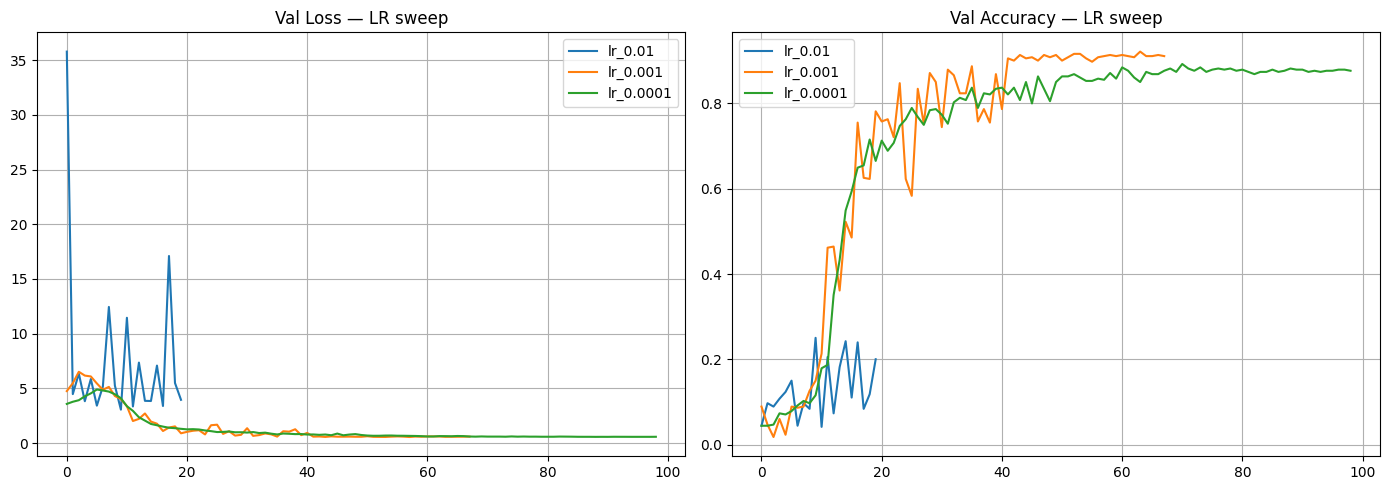

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1775902533.874474  512506 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_164956__.94


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1189 - loss: 3.3581

I0000 00:00:1775902543.590208  512507 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_164956__.94


48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 280ms/step - accuracy: 0.1596 - loss: 3.0423 - val_accuracy: 0.0449 - val_loss: 5.4919 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.2836 - loss: 2.6120 - val_accuracy: 0.0475 - val_loss: 6.3848 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3575 - loss: 2.3173 - val_accuracy: 0.0897 - val_loss: 6.8662 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4274 - loss: 2.0769 - val_accuracy: 0.0897 - val_loss: 7.2987 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4835 - loss: 1.9046 - val_accuracy: 0.0369 - val_loss: 6.3761 - learning_rate: 0.0010
Epoch 6/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4941 - loss: 1.8282
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5112 - loss: 1.7638 - val_accuracy

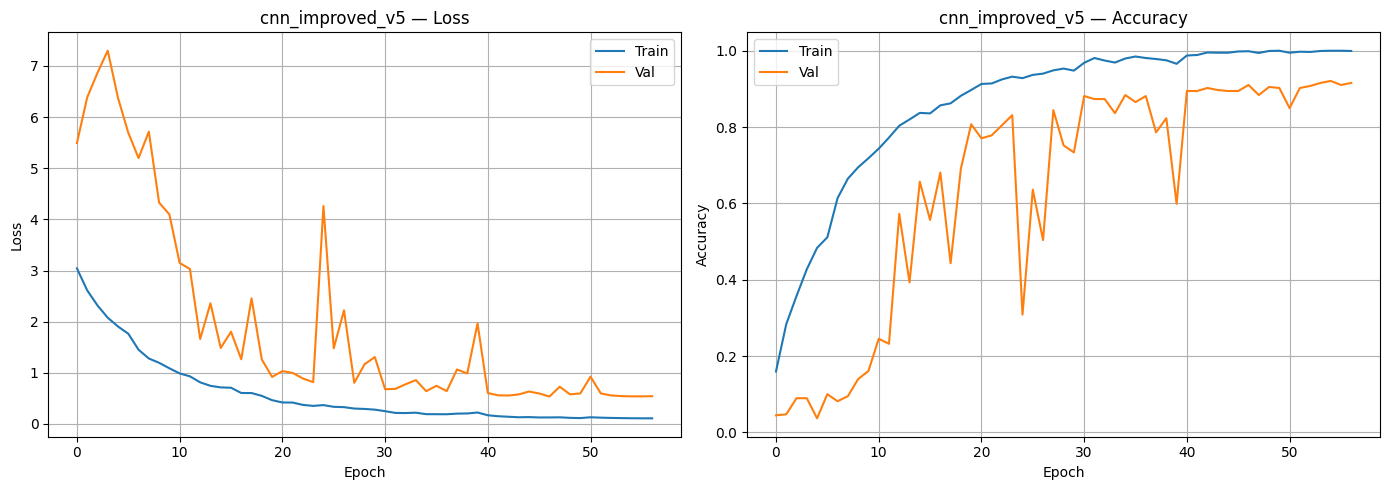

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

cnn_improved_v5 (best LR=0.001):
  Train — Loss: 0.1093, Acc: 1.0000
  Val   — Loss: 0.5353, Acc: 0.9103


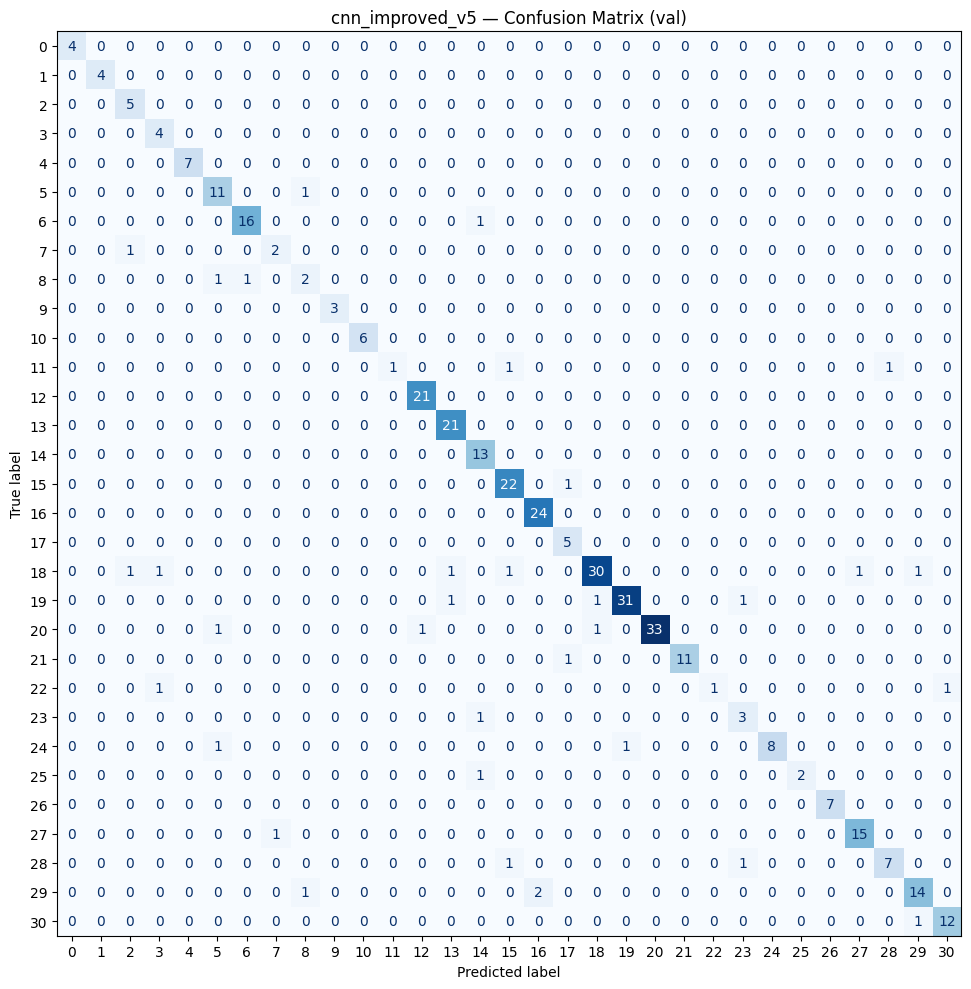

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 58 epochs
Epoch 1/58


I0000 00:00:1775902722.392340  512510 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_478639__.94


58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1590 - loss: 3.2945

I0000 00:00:1775902732.027426  512509 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_478639__.94


60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 341ms/step - accuracy: 0.2274 - loss: 2.9283
Epoch 2/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3219 - loss: 2.4652
Epoch 3/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.4269 - loss: 2.1715
Epoch 4/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.4802 - loss: 1.9209
Epoch 5/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5425 - loss: 1.6383
Epoch 6/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6116 - loss: 1.4767
Epoch 7/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6475 - loss: 1.3125
Epoch 8/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6939 - loss: 1.1922
Epoch 9/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7414 - loss: 1.0186
Epoch 10/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7668 - loss: 0.9360
Epoch 11/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7773 - loss: 0.8771
Epoch 12/58
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7963 -

In [14]:
X_test, test_filenames = load_data('test')

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_cnn_improved_v5.csv


,row_id,similarity
0,0,0.890866
1,1,0.685221
2,2,0.595747
3,3,0.565578
4,4,0.545938


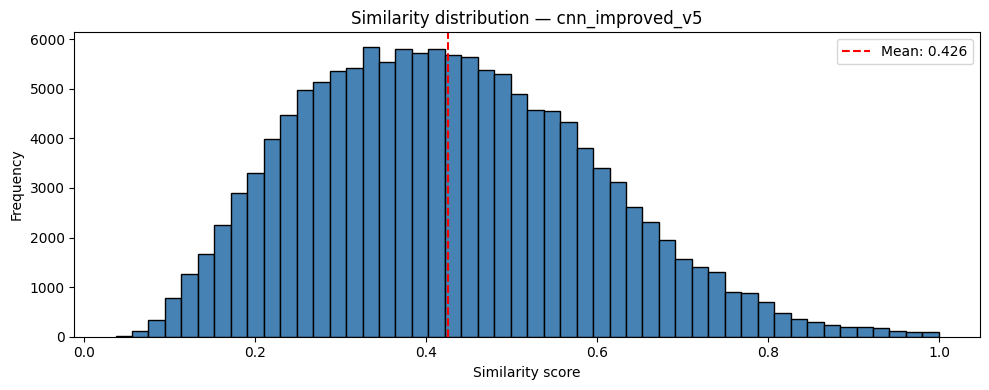

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | 1.0000 | 0.9103 |
| Loss     | 0.1093 | 0.5353 |
| Overfitting ? | — | Réduit : gap = 9.0 pts (vs 10.8 en v4) |
| Kaggle Score (public) | — | 0.404 |
| Kaggle Score (private) | — | 0.409 |

### Comparaison vs v4

| Métrique | v4 | v5 | Diff |
|----------|----|----|------|
| Sweep best val_acc | 0.9024 | 0.9103 | **+0.8 pts** |
| Section 4 val_acc | 0.8918 | 0.9103 | **+1.9 pts** |
| Gap overfitting | 10.8 pts | 9.0 pts | **−1.8 pts** |
| Train loss (section 4) | 0.0121 | 0.1093 | +0.097 (inclut pénalité L2) |
| Final train acc (retrain) | 0.9657 | 0.9763 | +1.1 pts |
| Kaggle public | 0.387 | 0.404 | **+0.017** |
| Kaggle private | 0.393 | 0.409 | **+0.016** |

Toutes les métriques sont en hausse. Le L2 a réduit l'overfitting de 1.8 pts tout en améliorant la val_acc de +1.9 pts et le Kaggle de +1.7 pts. C'est le **meilleur score CNN obtenu** sur cette compétition.

### Analyse des hyperparamètres — modification par modification

#### 1. L2 regularization (1e-4) sur Conv2D — seule modification, effet clair

La pénalité L2 ajoute un terme `λ × Σ(w²)` à la loss, ce qui force les poids des convolutions à rester petits. Avec 1.64M paramètres, c'est un frein direct à la mémorisation.

**Preuve chiffrée** :
- Gap d'overfitting : 10.8 pts (v4) → 9.0 pts (v5) → **−1.8 pts**. Le L2 a réduit la capacité effective du réseau sans toucher à l'architecture
- Train loss : 0.0121 (v4) → 0.1093 (v5). La loss monte car elle inclut la pénalité L2 (~0.09 de pénalité), mais ce n'est pas une dégradation — c'est le prix de la régularisation
- Val_acc : 89.18% → 91.03% (+1.9 pts). Le modèle généralise mieux car les poids sont plus lisses et moins spécialisés sur le train set
- Kaggle : 0.387 → 0.404 (+1.7 pts). Les embeddings sont plus robustes car les features convolutionnelles sont moins bruitées

**Verdict** : **Positif**. Le L2 est complémentaire au Dropout — le Dropout régularise les activations (couche embedding), le L2 régularise les poids (couches conv). Les deux ensemble contiennent l'overfitting d'un modèle 4× plus gros que v2.

#### 2. LR sweep — lr=0.01 s'effondre avec L2

| LR | v4 val_acc | v5 val_acc | Diff |
|----|-----------|-----------|------|
| 0.01 | 0.8865 | 0.2507 | **−63.6 pts** |
| 0.001 | 0.9024 | 0.9103 | +0.8 pts |
| 0.0001 | 0.9024 | 0.8813 | −2.1 pts |

Le lr=0.01 **s'effondre complètement** en v5 (25% = quasiment le hasard pour 31 classes). Avec L2, un LR trop élevé empêche les poids de se stabiliser : à chaque step, le gradient de la loss tire dans une direction, et la pénalité L2 tire les poids vers zéro. Le réseau oscille sans converger. En v4 sans L2, le lr=0.01 fonctionnait (88.65%) car il n'y avait pas ce tiraillement.

Le lr=0.001 reste optimal : assez fort pour apprendre, assez doux pour laisser le L2 stabiliser les poids.

#### 3. LR schedule — convergence plus tardive avec L2

4 réductions de LR : epoch 6 (→5e-4), 40 (→2.5e-4), 52 (→1.25e-4), 57 (→6.25e-5). EarlyStopping à epoch 57, best epoch 58 au sweep.

**Comparaison v4** : 4 réductions aussi, EarlyStopping à epoch 50, best epoch 46. Le modèle v5 converge **plus lentement** (+12 epochs) car le L2 freine l'apprentissage. Mais la première réduction arrive très tôt (epoch 6 vs 22 en v4) — le modèle met plus de temps à descendre dans le paysage de loss au début car le L2 contraint les poids dès le départ.

#### 4. Bilan de la régularisation cumulée

| Composant | Cible | Ajouté en | Effet mesuré |
|-----------|-------|-----------|-------------|
| BatchNorm | Stabilise le training | v2 | Convergence fiable |
| Augmentation moderate | Varier les inputs | v2 | +val_acc vs none |
| Dropout 0.5 | Activations (embedding) | v3 (évalué en v4) | Contient 1.64M params |
| L2 (1e-4) | Poids (conv) | v5 | −1.8 pts overfitting, +1.9 pts val_acc |

Les 4 régularisations sont complémentaires et agissent à des niveaux différents. Le modèle est maintenant **optimalement régularisé** pour sa taille : ajouter plus de régularisation (L2 plus fort, Dropout plus élevé, heavy aug) a déjà montré des effets négatifs dans les versions précédentes.

### Verdict

- [ ] Improvable → Instructions for vN+1
- [x] Not Improvable → **Plafond CNN from scratch atteint**
- [ ] Dead-end → On abandonne cette architecture

**Justification — pourquoi on ne peut pas aller plus haut :**

1. **Features apprises from scratch** : avec 1516 images (~49/classe), le CNN doit inventer ses propres détecteurs de bords, textures et formes. Un ResNet pré-entraîné sur ImageNet (1.2M images) a déjà ces features bas-niveau — il n'a qu'à fine-tuner les couches hautes. Notre CNN part de zéro à chaque entraînement.

2. **Profondeur limitée** : 5 blocs convolutionnels est le maximum viable sans skip connections. Aller plus profond causerait du vanishing gradient — c'est exactement le problème que les ResNets résolvent avec leurs connexions résiduelles.

3. **Régularisation saturée** : on empile déjà BatchNorm + augmentation moderate + Dropout 0.5 + L2(1e-4). Augmenter l'un quelconque de ces paramètres a déjà montré des effets négatifs (heavy aug en v3, et le lr=0.01 qui s'effondre avec L2 montre qu'on est à la limite).

4. **Objectif d'entraînement inadapté** : on entraîne en classification (softmax + cross-entropy) mais on évalue en re-ID (cosine similarity). Ce décalage est un plafond structurel — des losses contrastives (triplet loss, ArcFace) optimiseraient directement la qualité des embeddings, mais ce sont des approches fondamentalement différentes qui nécessitent un pipeline d'entraînement repensé.

5. **Le score Kaggle (0.404/0.409) est cohérent avec les limites théoriques** d'un CNN simple sur un problème de re-ID fine-grained avec peu de données. Le passage au transfer learning (ResNet, EfficientNet) devrait permettre un bond significatif.

### Récapitulatif de la progression CNN

| Version | Architecture | Régularisation | Kaggle (pub/priv) | Changement clé |
|---------|-------------|---------------|-------------------|---------------|
| v1 | 4 blocs, no BN | Dropout 0.3 | baseline | — |
| v2 | 4 blocs + BN | Dropout 0.3, aug moderate | 0.361 / 0.343 | +BatchNorm |
| v3 | 5 blocs + BN | Dropout 0.5, aug heavy | 0.292 / 0.298 | Heavy aug = erreur |
| v4 | 5 blocs + BN | Dropout 0.5, aug moderate | 0.387 / 0.393 | Revert aug → best |
| v5 | 5 blocs + BN | Dropout 0.5, aug moderate, L2 | **0.404 / 0.409** | +L2 → plafond |

**Progression totale** : +4.3 pts (public) / +6.6 pts (private) entre v2 et v5.

### Interprétation

_Ce notebook clôt l'exploration des CNN from scratch. Le L2(1e-4) était la dernière brique de régularisation manquante : il agit sur les poids des convolutions, là où le Dropout agit sur les activations. Ensemble, ils permettent à un modèle 4× plus gros (1.64M vs 427K params) de généraliser correctement malgré seulement 1516 images. Le résultat le plus marquant de cette série est la décorrélation entre val_acc et Kaggle score : v5 classifie aussi bien que v2 (91% vs 91.6%) mais produit des embeddings nettement meilleurs (+4.3 pts Kaggle). L'architecture plus profonde n'améliore pas la classification mais enrichit la représentation interne — un phénomène bien documenté en re-ID. Le plafond est maintenant structurel : pour aller plus loin, il faut soit des features pré-entraînées (transfer learning), soit une loss qui optimise directement la similarité (contrastive learning). Les deux pistes convergent vers les architectures ResNet/EfficientNet avec fine-tuning._